# Round 2 Leakage Tool Prototype Cases

This notebook contains two independent real-CO2 prototype runs with the same toy geometry: a top-anchored case and a bottom-anchored reservoir-pressure case. It does not include dummy-fluid or SCREEN/WellClass work.

## Prerequisites

Running this notebook requires a local clone of the leakage tool prototype (`leakage_model` package) under `work/benchmark/repos/leakage_tool_prototype`:

```bash
mkdir -p work/benchmark/repos
git clone git@gitlab.sintef.no:1630/research-projects/legacy/leakage_tool_prototype.git work/benchmark/repos/leakage_tool_prototype
```

It also requires `thermopack` (used for the real-CO2 Peng-Robinson solver cases below). It is already listed in `pyproject.toml`, so `uv sync` should install it; if it is missing from your environment, run the cell below (or `uv add thermopack` from a terminal).

See [docs/openiam_benchmarking.md](../docs/openiam_benchmarking.md) for details. This checkout lives under the SCREEN-ignored `work/` folder and is not part of this repository.

In [9]:
# Uncomment to install thermopack into the current environment if it's missing
# !uv add thermopack

## Scope

Each case builds a fresh Peng-Robinson CO2 solver and fresh well geometry. The cases do not share solver state. The bottom-anchored case demonstrates the pressure-boundary customization required when reservoir pressure, rather than the CO2 column, is the source condition.

In [10]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "pyproject.toml").exists())

prototype_root = repo_root / "work" / "benchmark" / "repos" / "leakage_tool_prototype"
prototype_examples = prototype_root / "examples"
for path in (prototype_root, prototype_examples):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

round2_root = repo_root / "notebooks" / "results" / "08A_round2_leakage_tool_prototype"
round2_root.mkdir(parents=True, exist_ok=True)

if not prototype_root.exists():
    raise FileNotFoundError(
        f"Expected leakage_tool_prototype checkout at {prototype_root}\n"
        "Clone it under work/benchmark/repos/leakage_tool_prototype; see docs/openiam_benchmarking.md."
    )

prototype_root.relative_to(repo_root)

PosixPath('work/benchmark/repos/leakage_tool_prototype')

In [11]:
from leakage_model.flow_solver import FlowSolver
from leakage_model.plotting import visualizeAll
from leakage_model.reservoir_permeabilities import MILLIDARCY
from leakage_model.state import FormationBC, TopBC
import example_well_builder as prototype_bcs

## Prototype Complex-Flow Case

This section reproduces `examples/co2_example_complex_flow.py` through the SCREEN notebook. The geometry and boundary-condition construction come directly from `example_well_builder.py`; the notebook adds tabular summaries and saved artifacts.

In [12]:
complex_flow_parameters = pd.DataFrame(
    [
        ["well_length_m", 1000.0, "m"],
        ["n_cells", 25, "count"],
        ["microannulus_aperture_m", 1.0e-4, "m"],
        ["microannulus_axial_perm_m2", (1.0e-4) ** 2 / 12.0, "m2"],
        ["cement_perm_m2", 1.0e-16, "m2"],
        ["cement_perm_mD", 1.0e-16 / MILLIDARCY, "mD"],
        ["casing_perm_m2", 1.0e-19, "m2"],
        ["formation_window_perm_m2", 1.0e-13, "m2"],
        ["deep_window_m", "800-1000", "m"],
        ["shallow_window_m", "100-250", "m"],
        ["pressure_offset_bar", 5.0, "bar"],
    ],
    columns=["quantity", "value", "unit"],
)
complex_flow_parameters.style.format(
    {"value": lambda value: f"{value:.6e}" if isinstance(value, float) else value}
)

,quantity,value,unit
0,well_length_m,1.000000e+03,m
1,n_cells,25,count
2,microannulus_aperture_m,1.000000e-04,m
3,microannulus_axial_perm_m2,8.333333e-10,m2
4,cement_perm_m2,1.000000e-16,m2
5,cement_perm_mD,1.013250e-01,mD
6,casing_perm_m2,1.000000e-19,m2
7,formation_window_perm_m2,1.000000e-13,m2
8,deep_window_m,800-1000,m
9,shallow_window_m,100-250,m


In [13]:
# Reproduce leakage_tool_prototype/examples/co2_example_complex_flow.py.
deep_window = (800.0, 1000.0)
shallow_window = (100.0, 250.0)
pressure_offset_pa = 5.0e5

co2_fs = prototype_bcs.build_well(
    "co2_complex_flow",
    lid=False,
    microannuli=True,
    components="CO2",
)
co2_fluid_model = "pure_fluid CO2 (thermopack PR)"
co2_windows = [
    (*deep_window, +pressure_offset_pa),
    (*shallow_window, -pressure_offset_pa),
]
prototype_bcs.set_water_bcs(
    co2_fs,
    co2_windows,
    top_open=True,
    bottom_open=True,
    bottom_dp=pressure_offset_pa,
)
co2_result = co2_fs.solve_system()
prototype_bcs.report("co2_complex_flow", co2_fs, co2_result)

co2_flows = co2_result.flows.total()
co2_result_summary = pd.DataFrame(
    [
        ["fluid_model", co2_fluid_model],
        ["case", "co2_complex_flow"],
        ["convergence_status", co2_result.convergence.status],
        ["top_pressure_bar", co2_fs.p_top / 1.0e5],
        ["bottom_pressure_bar", co2_fs.p_bottom / 1.0e5],
        ["top_leak_kg_s_positive_upward", -float(np.sum(co2_flows.top))],
        ["formation_outflow_kg_s", float(np.sum(co2_flows.formation[co2_flows.formation > 0]))],
        ["formation_inflow_kg_s", float(np.sum(co2_flows.formation[co2_flows.formation < 0]))],
    ],
    columns=["quantity", "value"],
)
co2_result_summary


Newton finished after 32 function evaluations.
Mass-balance check:
  max |residual| = 4.327e-13 kg/s,  max |flow| = 6.017e-04 kg/s,  ratio = 7.19e-10
-> PASS (relative mass-balance residual < 1e-06)

______________________________________________________________

CO2 leakage at the top of well into the air is -7.282e-04 kg/s.
CO2 leakage radially into the reservoir is 7.320e-04 kg/s.
CO2 leakage into bottom of well is 3.846e-06 kg/s.

______________________________________________________________


=== co2_complex_flow ===
  convergence: PASS
  out of the top         :    -0.728 g/s
  out to the formation   :    +1.069 g/s
  in from the formation  :    -0.337 g/s
  out of the bottom      :    +0.004 g/s


,quantity,value
0,fluid_model,pure_fluid CO2 (thermopack PR)
1,case,co2_complex_flow
2,convergence_status,PASS
3,top_pressure_bar,10.81
4,bottom_pressure_bar,18.064549
5,top_leak_kg_s_positive_upward,-0.000728
6,formation_outflow_kg_s,0.001069
7,formation_inflow_kg_s,-0.000337


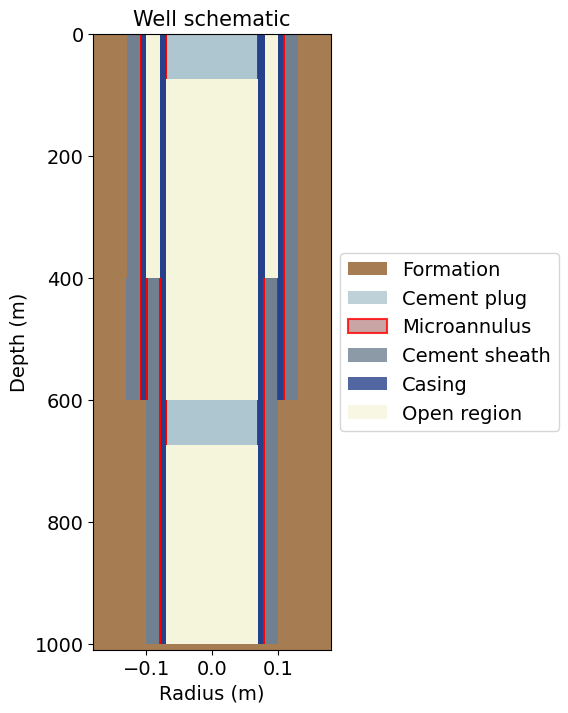

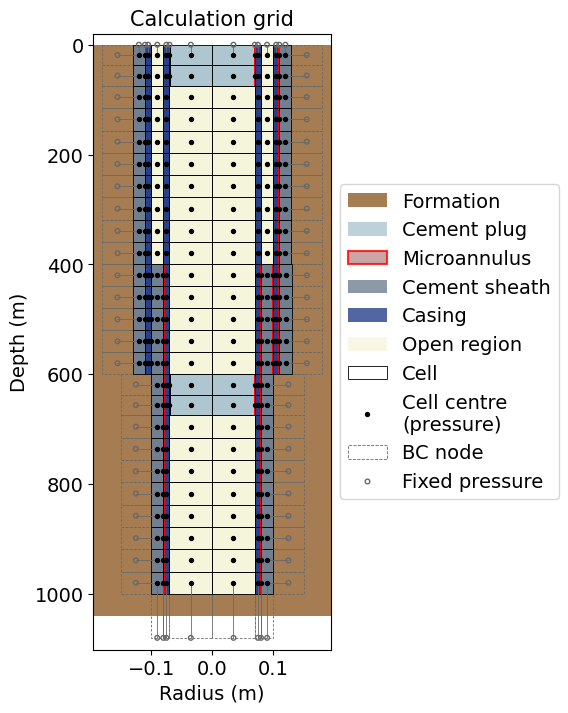

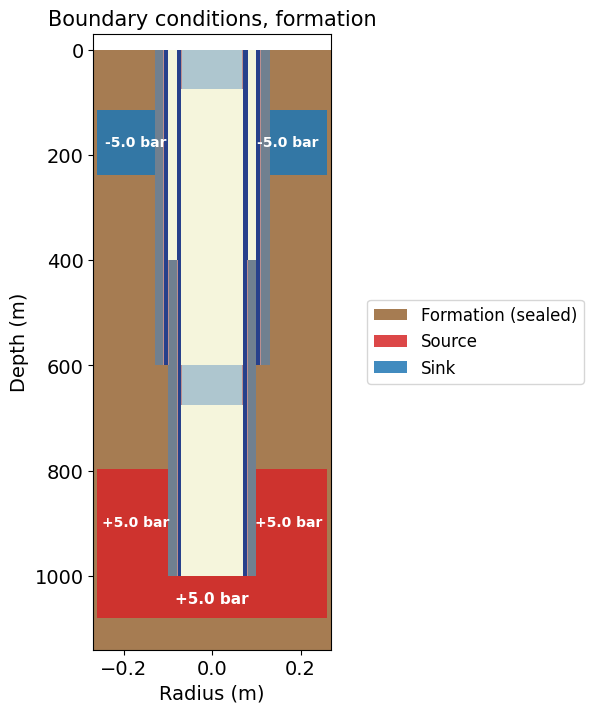

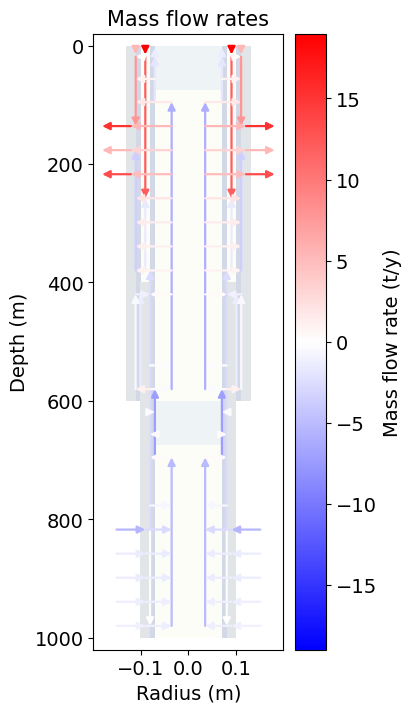

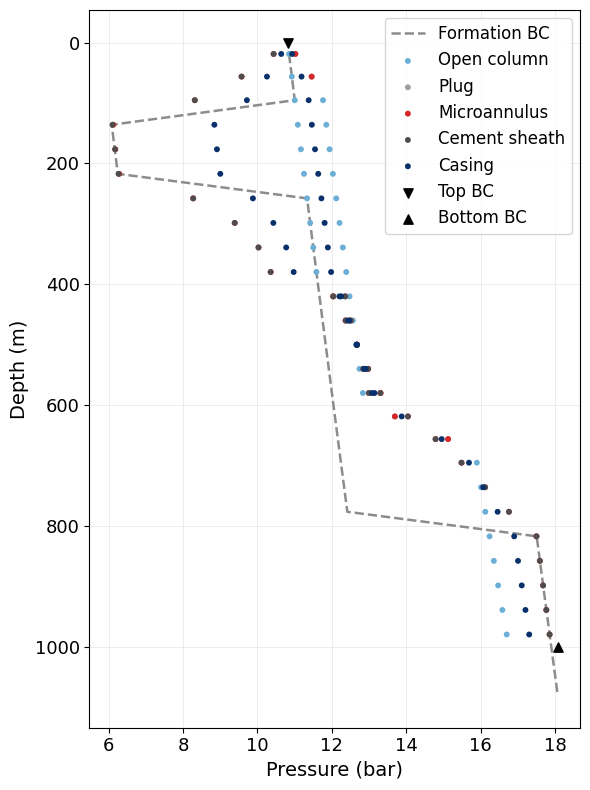

,real_co2_visualization
0,notebooks/results/08A_round2_leakage_tool_prot...
1,notebooks/results/08A_round2_leakage_tool_prot...
2,notebooks/results/08A_round2_leakage_tool_prot...
3,notebooks/results/08A_round2_leakage_tool_prot...
4,notebooks/results/08A_round2_leakage_tool_prot...


In [14]:
co2_visualization_dir = round2_root / "prototype_visualizations_real_co2"
co2_visualization_dir.mkdir(parents=True, exist_ok=True)
co2_fs.directory = str(co2_visualization_dir)
visualizeAll(co2_fs, co2_result, show=True)

co2_prototype_pngs = sorted(co2_visualization_dir.glob("*.png"))
pd.DataFrame({
    "real_co2_visualization": [path.relative_to(repo_root).as_posix() for path in co2_prototype_pngs]
})

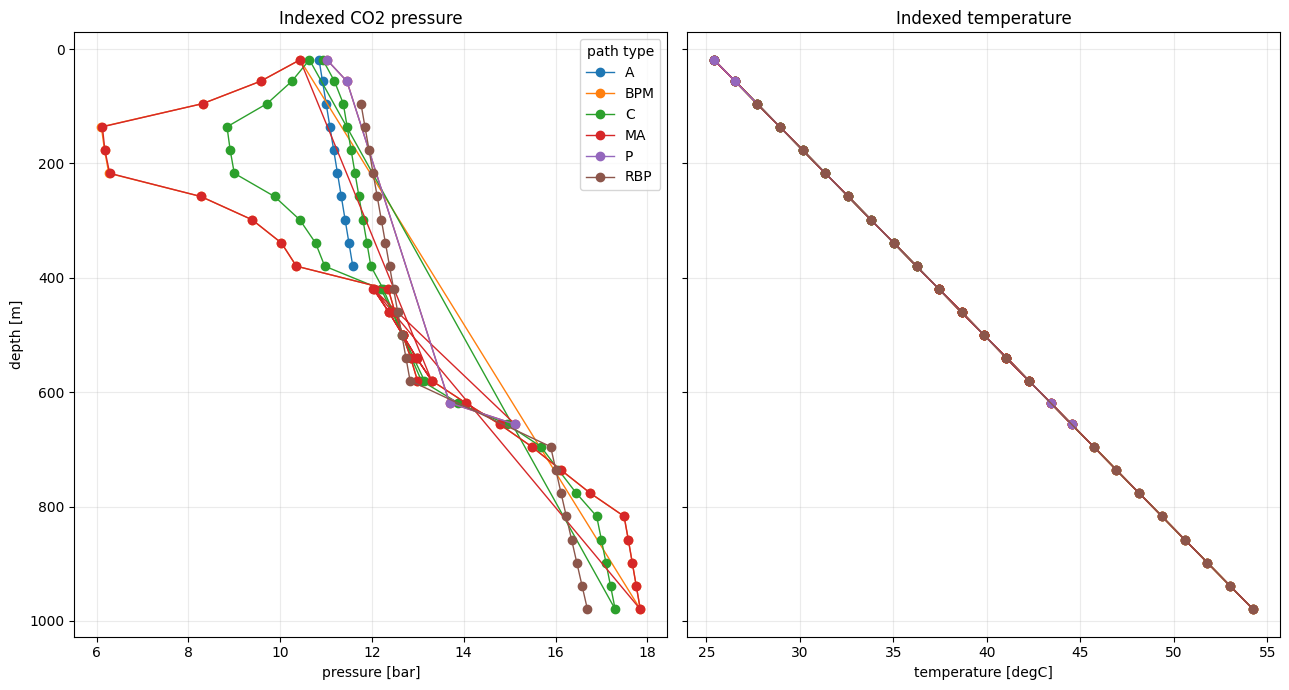

,node_index,path_index,path_name,path_type,depth_m,pressure_pa,pressure_bar,temperature_k,temperature_c
0,0,0,Plug 1,P,18.7500,1.101839e+06,11.018393,298.562500,25.412500
1,1,0,Plug 1,P,56.2500,1.145460e+06,11.454600,299.687500,26.537500
2,2,1,Blank 1,RBP,95.3125,1.176003e+06,11.760033,300.859375,27.709375
3,3,1,Blank 1,RBP,135.9375,1.184832e+06,11.848322,302.078125,28.928125
4,4,1,Blank 1,RBP,176.5625,1.193688e+06,11.936881,303.296875,30.146875


In [15]:
# Index solved pressures and temperatures for reproducible replotting.
formation_depths = np.append(
    co2_fs.well.xList,
    co2_fs.well.wellLen + co2_fs.well.bottom_BC_dist,
)
node_depths = np.array([node.x for node in co2_fs.well.nodes], dtype=float)
node_temperatures_k = np.interp(node_depths, formation_depths, co2_fs.T)

indexed_pressure_temperature = pd.DataFrame(
    [
        {
            "node_index": node_index,
            "path_index": int(node.inPath),
            "path_name": co2_fs.well.paths[node.inPath].name,
            "path_type": co2_fs.well.paths[node.inPath].pathType,
            "depth_m": float(node.x),
            "pressure_pa": float(co2_result.p[node_index]),
            "pressure_bar": float(co2_result.p[node_index] / 1.0e5),
            "temperature_k": float(node_temperatures_k[node_index]),
            "temperature_c": float(node_temperatures_k[node_index] - 273.15),
        }
        for node_index, node in enumerate(co2_fs.well.nodes)
    ]
)
indexed_pressure_temperature_csv = round2_root / "co2_complex_flow_indexed_pressure_temperature.csv"
indexed_pressure_temperature.to_csv(indexed_pressure_temperature_csv, index=False)

fig, (pressure_axis, temperature_axis) = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for path_type, path_data in indexed_pressure_temperature.groupby("path_type"):
    pressure_axis.plot(
        path_data["pressure_bar"],
        path_data["depth_m"],
        marker="o",
        linewidth=1.0,
        label=path_type,
    )
    temperature_axis.plot(
        path_data["temperature_c"],
        path_data["depth_m"],
        marker="o",
        linewidth=1.0,
        label=path_type,
    )

pressure_axis.set_xlabel("pressure [bar]")
temperature_axis.set_xlabel("temperature [degC]")
pressure_axis.set_ylabel("depth [m]")
pressure_axis.invert_yaxis()
pressure_axis.grid(alpha=0.25)
temperature_axis.grid(alpha=0.25)
pressure_axis.set_title("Indexed CO2 pressure")
temperature_axis.set_title("Indexed temperature")
pressure_axis.legend(title="path type")
fig.tight_layout()
indexed_plot_path = co2_visualization_dir / "indexed_pressure_temperature.png"
fig.savefig(indexed_plot_path, dpi=150, bbox_inches="tight")
plt.show()

indexed_pressure_temperature.head()

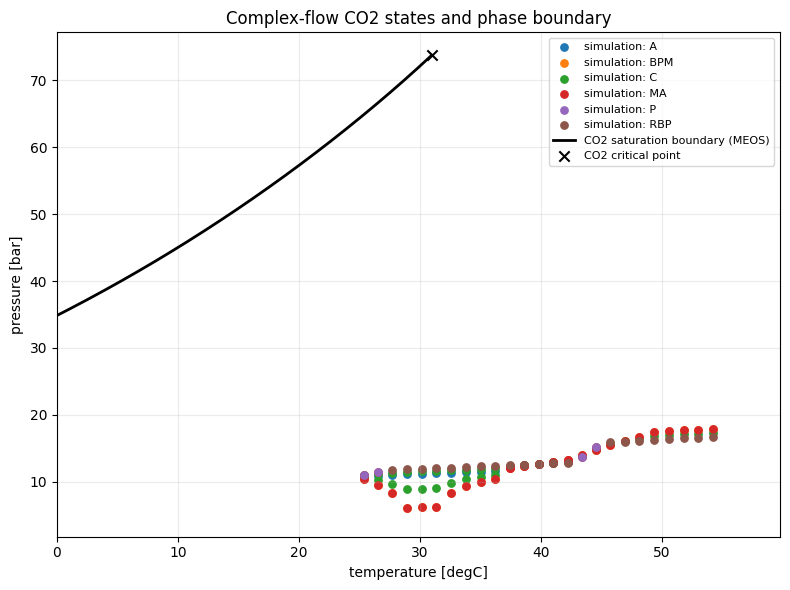

,temperature_c,pressure_bar
0,-56.467757,5.200000
1,-56.027817,5.300107
2,-55.594113,5.400213
3,-55.166440,5.500320
4,-54.744602,5.600426


In [17]:
# Overlay the real CO2 saturation boundary from Thermopack MEOS.
from thermopack.multiparameter import multiparam

co2_meos = multiparam("CO2", "MEOS")
co2_boundary_temperature_k, co2_boundary_pressure_pa = co2_meos.get_envelope_twophase(
    initial_pressure=5.2e5,
    z=np.array([1.0]),
    maximum_pressure=8.0e6,
    minimum_temperature=216.6,
    step_size_factor=0.5,
)

co2_boundary = pd.DataFrame(
    {
        "temperature_c": co2_boundary_temperature_k - 273.15,
        "pressure_bar": co2_boundary_pressure_pa / 1.0e5,
    }
).sort_values("temperature_c")

fig, axis = plt.subplots(figsize=(8, 6))
for path_type, path_data in indexed_pressure_temperature.groupby("path_type"):
    axis.scatter(
        path_data["temperature_c"],
        path_data["pressure_bar"],
        s=28,
        label=f"simulation: {path_type}",
    )
axis.plot(
    co2_boundary["temperature_c"],
    co2_boundary["pressure_bar"],
    color="black",
    linewidth=2.0,
    label="CO2 saturation boundary (MEOS)",
)
axis.scatter(
    [30.978],
    [73.773],
    color="black",
    marker="x",
    s=55,
    label="CO2 critical point",
)
axis.set_xlabel("temperature [degC]")
axis.set_ylabel("pressure [bar]")
axis.set_xlim(left=0)
axis.set_title("Complex-flow CO2 states and phase boundary")
axis.grid(alpha=0.25)
axis.legend(fontsize=8)
fig.tight_layout()
phase_boundary_plot_path = co2_visualization_dir / "co2_phase_boundary_overlay.png"
fig.savefig(phase_boundary_plot_path, dpi=150, bbox_inches="tight")
plt.show()

co2_boundary.head()